In [ ]:
'''
19 years (2006-2025) -> 6935 days
  yellow       1474 rows
  amber         448 rows
  red            20 rows

1942 / 6935
aprox 29% warnings

200000 days
Yellow: 42509
Amber: 12920
Red: 577



Lines for 
x = warning_rows[i] * (6935/200000)
x = ... when total warning_rows = (1942/6935)*200000
'''

In [1]:
import pandas as pd

# Get total historical flood warnings (excludes duplicate same day warnings (same day, different area))
total = 0
warning_rows = []
warnings = ['yellow', 'amber', 'red']
for warning in warnings:
    csv_path = f"warning/{warning}_warnings.csv"
    df = pd.read_csv(csv_path)
    rows = len(df)
    print(f"  {warning:<10} {rows:>6} rows")
    total += rows
    warning_rows.append(rows)
print(f"  {'TOTAL':<10} {total:>6} rows\n")

  yellow       1474 rows
  amber         448 rows
  red            20 rows
  TOTAL        1942 rows



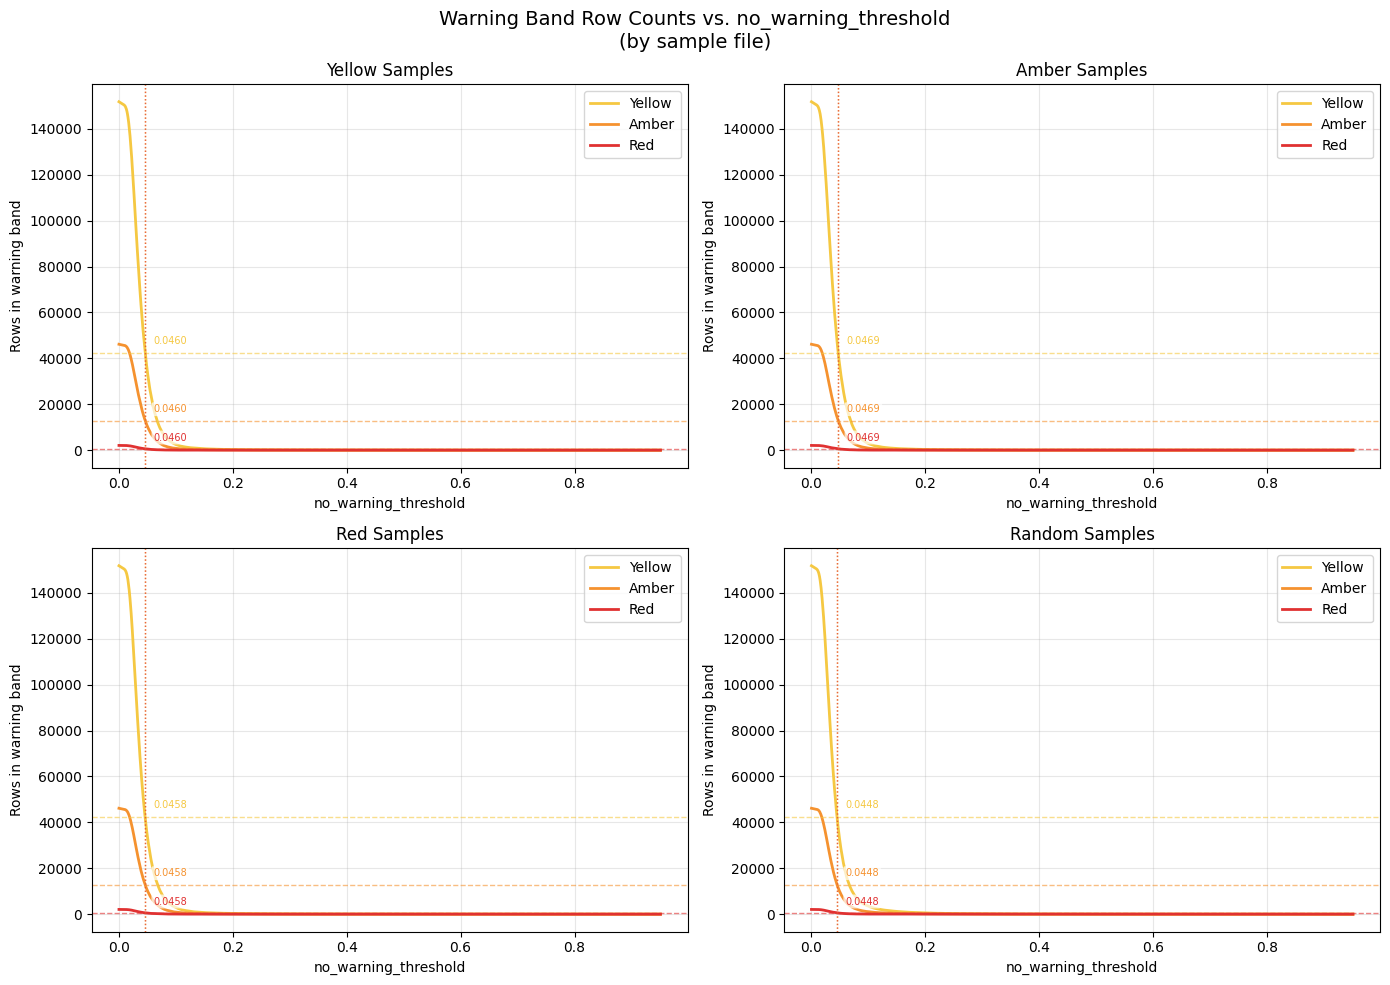

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load warning row counts
warnings = ['yellow', 'amber', 'red']
warning_rows = []
for warning in warnings:
    df = pd.read_csv(f"warning/{warning}_warnings.csv")
    warning_rows.append(len(df))
total = sum(warning_rows)

# Load all sample dataframes upfront
sample_dfs = {}
for w in ['yellow', 'amber', 'red', 'random']:
    sample_dfs[w] = pd.read_csv(f"warning/samples/{w}_samples.csv")

# Sweep no_warning_threshold
thresholds = np.arange(0, 0.951, 0.0001)
colors = {'yellow': '#f5c842', 'amber': '#f5922f', 'red': '#e03131'}

# Threshold lines for yellow, amber, red counts
threshold_lines = {'yellow': 42509, 'amber': 12920, 'red': 577}

sample_names = ['yellow', 'amber', 'red', 'random']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, sample_name in zip(axes, sample_names):
    df_sample = sample_dfs[sample_name]
    results = {w: [] for w in warnings}

    for t in thresholds:
        df_filtered = df_sample.loc[df_sample['impact'] > t]
        for i, w in enumerate(warnings):
            p_start = t + (sum(warning_rows[:i])   / total) * (1 - t)
            p_end   = t + (sum(warning_rows[:i+1]) / total) * (1 - t)
            rows_in_range = int(len(df_filtered) * (p_end - p_start))
            results[w].append(rows_in_range)

    for w in warnings:
        ax.plot(thresholds, results[w], label=w.capitalize(), color=colors[w], linewidth=2)

    # Add horizontal lines and annotate where each warning curve crosses it
    for w, target in threshold_lines.items():
        ax.axhline(y=target, color=colors[w], linewidth=1, linestyle='--', alpha=0.6)

        # Find where the curve crosses the target (first crossing)
        curve = np.array(results[w])
        diffs = curve - target
        cross_idx = np.where(np.diff(np.sign(diffs)))[0]

        if len(cross_idx) > 0:
            idx = cross_idx[0]
            # Interpolate for a more precise x value
            x0, x1 = thresholds[idx], thresholds[idx + 1]
            y0, y1 = curve[idx], curve[idx + 1]
            x_cross = x0 + (target - y0) * (x1 - x0) / (y1 - y0)

            ax.axvline(x=x_cross, color=colors[w], linewidth=1, linestyle=':', alpha=0.6)
            ax.annotate(
                f'{x_cross:.4f}',
                xy=(x_cross, target),
                xytext=(6, 6),
                textcoords='offset points',
                fontsize=7,
                color=colors[w],
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none')
            )

    ax.set_title(f'{sample_name.capitalize()} Samples')
    ax.set_xlabel('no_warning_threshold')
    ax.set_ylabel('Rows in warning band')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Warning Band Row Counts vs. no_warning_threshold\n(by sample file)', fontsize=14)
plt.tight_layout()
plt.show()

In [3]:
# Find impact thresholds using historical samples and random
no_warning_threshold = 0.0448
warnings.append('random')
for warning in warnings:
    print(f"-- {warning.upper()} --")
    csv_path = f"warning/samples/{warning}_samples.csv"
    df = pd.read_csv(csv_path)
    print(f"Count: {len(df)}")
    df = df.loc[df['impact'] > no_warning_threshold]
    for i in range(3):
        p_start = no_warning_threshold + (sum(warning_rows[:i])   / total) * (1 - no_warning_threshold)
        p_end   = no_warning_threshold + (sum(warning_rows[:i+1]) / total) * (1 - no_warning_threshold)
        q_start = df['impact'].quantile(p_start)
        q_end   = df['impact'].quantile(p_end)
        rows_in_range = int(len(df) * (p_end - p_start))
        print(f"  [{warnings[i]}] {p_start:.4%} - {p_end:.4%}  ->  impact: {q_start:.4f} - {q_end:.4f} ({rows_in_range} rows)")
    print()

-- YELLOW --
Count: 200000
  [yellow] 4.4800% - 76.9808%  ->  impact: 0.0457 - 0.0710 (45481 rows)
  [amber] 76.9808% - 99.0163%  ->  impact: 0.0710 - 0.1761 (13823 rows)
  [red] 99.0163% - 100.0000%  ->  impact: 0.1761 - 0.9804 (617 rows)

-- AMBER --
Count: 200000
  [yellow] 4.4800% - 76.9808%  ->  impact: 0.0457 - 0.0721 (47672 rows)
  [amber] 76.9808% - 99.0163%  ->  impact: 0.0721 - 0.1846 (14489 rows)
  [red] 99.0163% - 100.0000%  ->  impact: 0.1846 - 0.9878 (646 rows)

-- RED --
Count: 200000
  [yellow] 4.4800% - 76.9808%  ->  impact: 0.0456 - 0.0725 (44901 rows)
  [amber] 76.9808% - 99.0163%  ->  impact: 0.0725 - 0.1869 (13647 rows)
  [red] 99.0163% - 100.0000%  ->  impact: 0.1869 - 1.0130 (609 rows)

-- RANDOM --
Count: 200000
  [yellow] 4.4800% - 76.9808%  ->  impact: 0.0456 - 0.0725 (42452 rows)
  [amber] 76.9808% - 99.0163%  ->  impact: 0.0725 - 0.2346 (12902 rows)
  [red] 99.0163% - 100.0000%  ->  impact: 0.2346 - 0.9280 (576 rows)



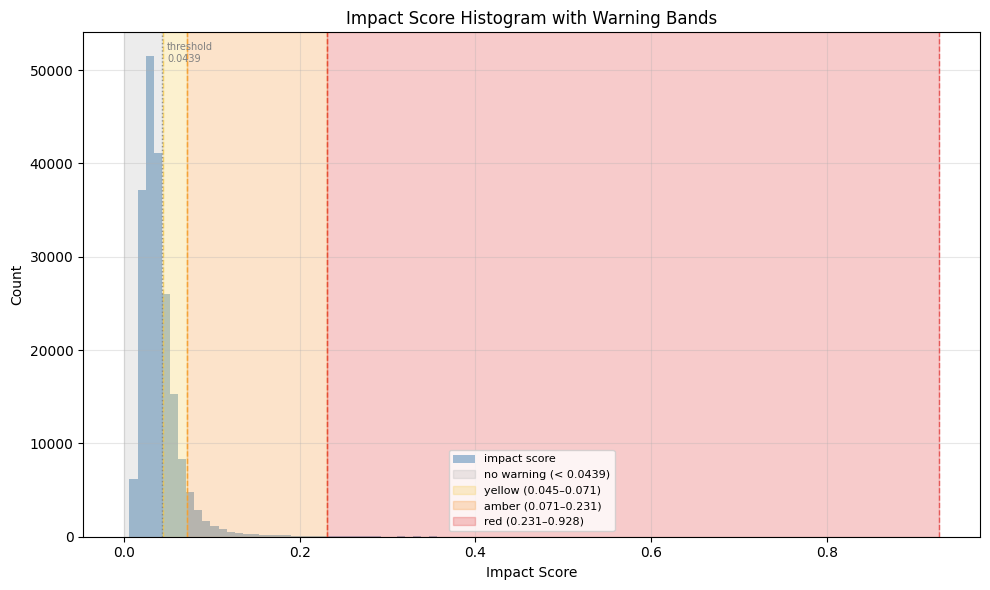

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

no_warning_threshold = 0.0439
warnings = ['yellow', 'amber', 'red']

# Load historical counts
warning_rows = []
total = 0
for w in warnings:
    df = pd.read_csv(f"warning/{w}_warnings.csv")
    warning_rows.append(len(df))
    total += len(df)

# Compute band boundaries (as impact score values now)
bands = []
for i in range(3):
    p_start = no_warning_threshold + (sum(warning_rows[:i])   / total) * (1 - no_warning_threshold)
    p_end   = no_warning_threshold + (sum(warning_rows[:i+1]) / total) * (1 - no_warning_threshold)
    bands.append((p_start, p_end))

colors = {'yellow': '#f5c842', 'amber': '#f5922f', 'red': '#e03131'}

df = pd.read_csv("warning/samples/random_samples.csv")

# Convert quantile boundaries to impact score values (using filtered df)
df_filtered = df.loc[df['impact'] > no_warning_threshold]
impact_bands = []
for p_start, p_end in bands:
    q_start = df_filtered['impact'].quantile(p_start)
    q_end   = df_filtered['impact'].quantile(p_end)
    impact_bands.append((q_start, q_end))

fig, ax = plt.subplots(figsize=(10, 6))

# Histogram on full data
ax.hist(df['impact'], bins=100, color='steelblue', alpha=0.5, label='impact score')

# Shade no-warning region
ax.axvspan(0, no_warning_threshold, alpha=0.15, color='gray', label=f'no warning (< {no_warning_threshold})')

# Shade warning bands using impact score boundaries
for i, (w, (q_start, q_end)) in enumerate(zip(warnings, impact_bands)):
    ax.axvspan(q_start, q_end, alpha=0.25, color=colors[w], label=f'{w} ({q_start:.3f}–{q_end:.3f})')
    ax.axvline(x=q_start, color=colors[w], linewidth=1, linestyle='--', alpha=0.7)
    ax.axvline(x=q_end,   color=colors[w], linewidth=1, linestyle='--', alpha=0.7)

# Threshold line
ax.axvline(x=no_warning_threshold, color='gray', linewidth=1, linestyle=':', alpha=0.8)
ax.text(no_warning_threshold + 0.005, 0.98, f'threshold\n{no_warning_threshold}',
        fontsize=7, color='gray', transform=ax.get_xaxis_transform(), va='top')

ax.set_title('Impact Score Histogram with Warning Bands')
ax.set_xlabel('Impact Score')
ax.set_ylabel('Count')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()